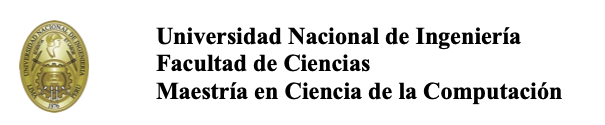

- *Asignatura: MCC225A* - Tópicos Especiales III: IA Generativa y aprendizaje multimodal   
- *Proyecto: POC* - Reconocimiento de Facturas

# Extracción de campos de facturas (Proforma Invoice)

Prueba comparativa de dos rutinas de extracción sobre el documento de demo `bills/PI-20260630141.pdf`.

**Arquitectura evaluada:** `PaddleOCR + LLM OpenAI + Qwen2.5-VL (fallback) + reglas Python`

## Campos objetivo a extraer

| Campo | Descripción |
|-------|-------------|
| `bill_to` | Persona a facturar (*Bill To*) |
| `company` | Empresa (*Company*) |
| `address` | Dirección de la empresa (*Add.*) |
| `total_amount_usd` | Total de la línea de producto — *Total Amount (USD)* |
| `freight_charge` | Cargo de flete — *Freight charge* |
| `handling_charge_intermediary_bank` | Cargo de manejo del banco intermediario — *Handing charge for intermediary bank* |
| `total_amount` | Monto total final — *Total Amount USD* |

## Rutas comparadas

1. **Ruta 1 — PaddleOCR + OpenAI:** OCR con PaddleOCR sobre la imagen del PDF → estructuración del texto con un LLM de OpenAI. Si OpenAI no está disponible, se usan **reglas Python** (regex) como fallback.
2. **Ruta 2 — Qwen2.5-VL (local):** modelo de visión-lenguaje servido localmente en `192.168.12.57`, que recibe la imagen directamente y devuelve los campos.

Al final se comparan ambos resultados contra el *ground truth* y se reporta la **precisión por campo** y **global** de cada ruta.

## 1. Configuración

Ajusta aquí las credenciales y endpoints. Las variables se leen desde el entorno (o desde un archivo `.env`) para no exponer secretos en el notebook.

- `OPENAI_API_KEY`: clave de OpenAI (necesaria para la Ruta 1 con LLM).
- `OPENAI_MODEL`: modelo de OpenAI (por defecto `gpt-4o-mini`).
- `QWEN_BASE_URL`: endpoint OpenAI-compatible del Qwen2.5-VL local (por defecto `http://192.168.12.57:8499/v1/vision/analyze1`).
- `QWEN_MODEL`: nombre del modelo servidor ( `Qwen2.5-VL-32B-Instruct-AWQ`).

In [1]:
!curl -X POST http://192.168.12.57:8499/v1/vision/analyze \
  -F "image_url=https://univirtual.uni.pe/pluginfile.php/1/theme_moove/sliderimage1/1778088997/UNI%20Dron.jpeg" \
  -F "prompt=¿Qué hay en esta imagen?"

{"response":"La imagen muestra un edificio de arquitectura moderna con un diseño distintivo, caracterizado por su coloración roja y blanca. El edificio tiene múltiples pisos y ventanas rectangulares, lo que sugiere que podría ser una institución pública, educativa o gubernamental. En la parte superior del edificio, se puede leer una inscripción que parece ser el nombre de la institución, aunque no está completamente claro debido a la resolución de la imagen.\n\nEn el frente del edificio, hay una plaza o área abierta con un pavimento oscuro y una bandera nacional de Perú (con colores rojo y blanco) colocada en un pedestal. Alrededor de la bandera, hay plantas y arbustos bien cuidados, lo que da una apariencia formal y ordenada al lugar. \n\nEl entorno alrededor del edificio incluye árboles y un muro perimetral, lo que indica que el edificio está rodeado por un área verde y bien mantenida. En el fondo, se pueden ver montañas, lo que sugiere que el edificio está ubicado en una zona con re

In [3]:
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage

llm = init_chat_model(
    model="Qwen/Qwen2.5-VL-32B-Instruct-AWQ",
    model_provider="openai",
    base_url="http://192.168.12.57:8499/v1",
    api_key="EMPTY",
)

message = HumanMessage(
    content=[
        {"type": "text", "text": "¿Qué hay en esta imagen?"},
        {
            "type": "image_url",
            "image_url": {"url": "https://univirtual.uni.pe/pluginfile.php/1/theme_moove/sliderimage1/1778088997/UNI%20Dron.jpeg"},
        },
    ]
)

response = llm.invoke([message])
print(response.content)


La imagen muestra un edificio de arquitectura moderna con un diseño destacado en colores rojo y blanco. Aquí hay algunos detalles visuales:

1. **Edificio principal**:
   - El edificio es grande y rectangular, con una fachada simétrica.
   - Tiene múltiples ventanas rectangulares distribuidas de manera uniforme.
   - La estructura está dominada por colores rojo y blanco, con líneas verticales que resaltan su diseño.
   - En la parte superior del edificio, se puede leer un texto que parece ser el nombre de la institución, aunque no es completamente legible en la imagen.

2. **Área alrededor del edificio**:
   - Frente al edificio, hay una plaza o área pavimentada con un diseño geométrico en el suelo.
   - En el centro de la plaza, hay un monumento o escultura sobre una base, rodeado por arbustos y flores.
   - Banderas peruanas (blanco y rojo) están colocadas en postes frente al edificio, indicando que este lugar podría ser de importancia institucional o gubernamental en Perú.

3. **Áre

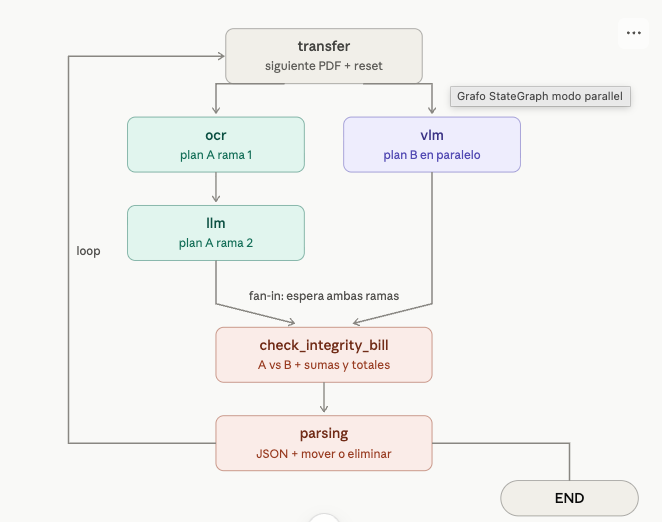

In [4]:
import os
from pathlib import Path

# --- Rutas del proyecto ---
PROJECT_DIR = Path.cwd()
PDF_PATH = PROJECT_DIR / "bills" / "PI-20260630141.pdf"
CACHE_DIR = PROJECT_DIR / ".cache"
IMG_DIR = CACHE_DIR / "images"

# Redirigir el cache de PaddleX/PaddleOCR al workspace
os.environ.setdefault("PADDLE_PDX_CACHE_HOME", str(CACHE_DIR / "paddlex"))
for _d in (CACHE_DIR, IMG_DIR, CACHE_DIR / "paddlex"):
    _d.mkdir(parents=True, exist_ok=True)

# --- Carga opcional de .env ---
try:
    from dotenv import load_dotenv
    load_dotenv(PROJECT_DIR / ".env")
except Exception:
    pass

# --- Configuración OpenAI (Ruta 1) ---
OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
OPENAI_MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o-mini")

# --- Configuración Qwen2.5-VL local (Ruta 2) ---
# Servido con vLLM/Ollama/LM Studio en modo OpenAI-compatible.
QWEN_BASE_URL = os.environ.get("QWEN_BASE_URL", "http://192.168.12.57:8499/v1")
QWEN_MODEL = os.environ.get("QWEN_MODEL", "Qwen/Qwen2.5-VL-32B-Instruct-AWQ")
QWEN_API_KEY = os.environ.get("QWEN_API_KEY", "EMPTY")  # los servidores locales suelen no requerir clave

# --- Campos objetivo ---
CAMPOS = [
    "bill_to",
    "company",
    "address",
    "total_amount_usd",
    "freight_charge",
    "handling_charge_intermediary_bank",
    "total_amount",
]

print("PDF de demo:", PDF_PATH, "| existe:", PDF_PATH.exists())
print("OpenAI configurado:", bool(OPENAI_API_KEY), "| modelo:", OPENAI_MODEL)
print("Qwen endpoint:", QWEN_BASE_URL, "| modelo:", QWEN_MODEL)

PDF de demo: /Users/soporte/Downloads/project/dhl2/bills/PI-20260630141.pdf | existe: True
OpenAI configurado: True | modelo: gpt-4o-mini
Qwen endpoint: http://192.168.12.57:8499/v1 | modelo: Qwen/Qwen2.5-VL-32B-Instruct-AWQ


## 2. Ground truth (valores reales del documento)

Valores verificados manualmente en `PI-20260630141.pdf`. Sirven como referencia para medir la precisión de cada ruta.

In [2]:
GROUND_TRUTH = {
    "bill_to": "Alex Segura",
    "company": "KADO Telecomunicaciones SAC",
    "address": "Calle Jose Marti 254 Maranga San Miguel - Lima - Peru - 15088 ZIP 15088",
    "total_amount_usd": 875.00,
    "freight_charge": 290.00,
    "handling_charge_intermediary_bank": 0.00,
    "total_amount": 1165.00,
}

import json
print(json.dumps(GROUND_TRUTH, indent=2, ensure_ascii=False))

{
  "bill_to": "Alex Segura",
  "company": "KADO Telecomunicaciones SAC",
  "address": "Calle Jose Marti 254 Maranga San Miguel - Lima - Peru - 15088 ZIP 15088",
  "total_amount_usd": 875.0,
  "freight_charge": 290.0,
  "handling_charge_intermediary_bank": 0.0,
  "total_amount": 1165.0
}


## 3. Conversión del PDF a imagen

Ambas rutas parten de una imagen rasterizada del PDF (PaddleOCR necesita imagen y Qwen2.5-VL es un modelo de visión). Usamos PyMuPDF a 200 DPI.

Imagen(es) generada(s): ['/Users/soporte/Downloads/project/dhl2/.cache/images/PI-20260630141_p1.png']


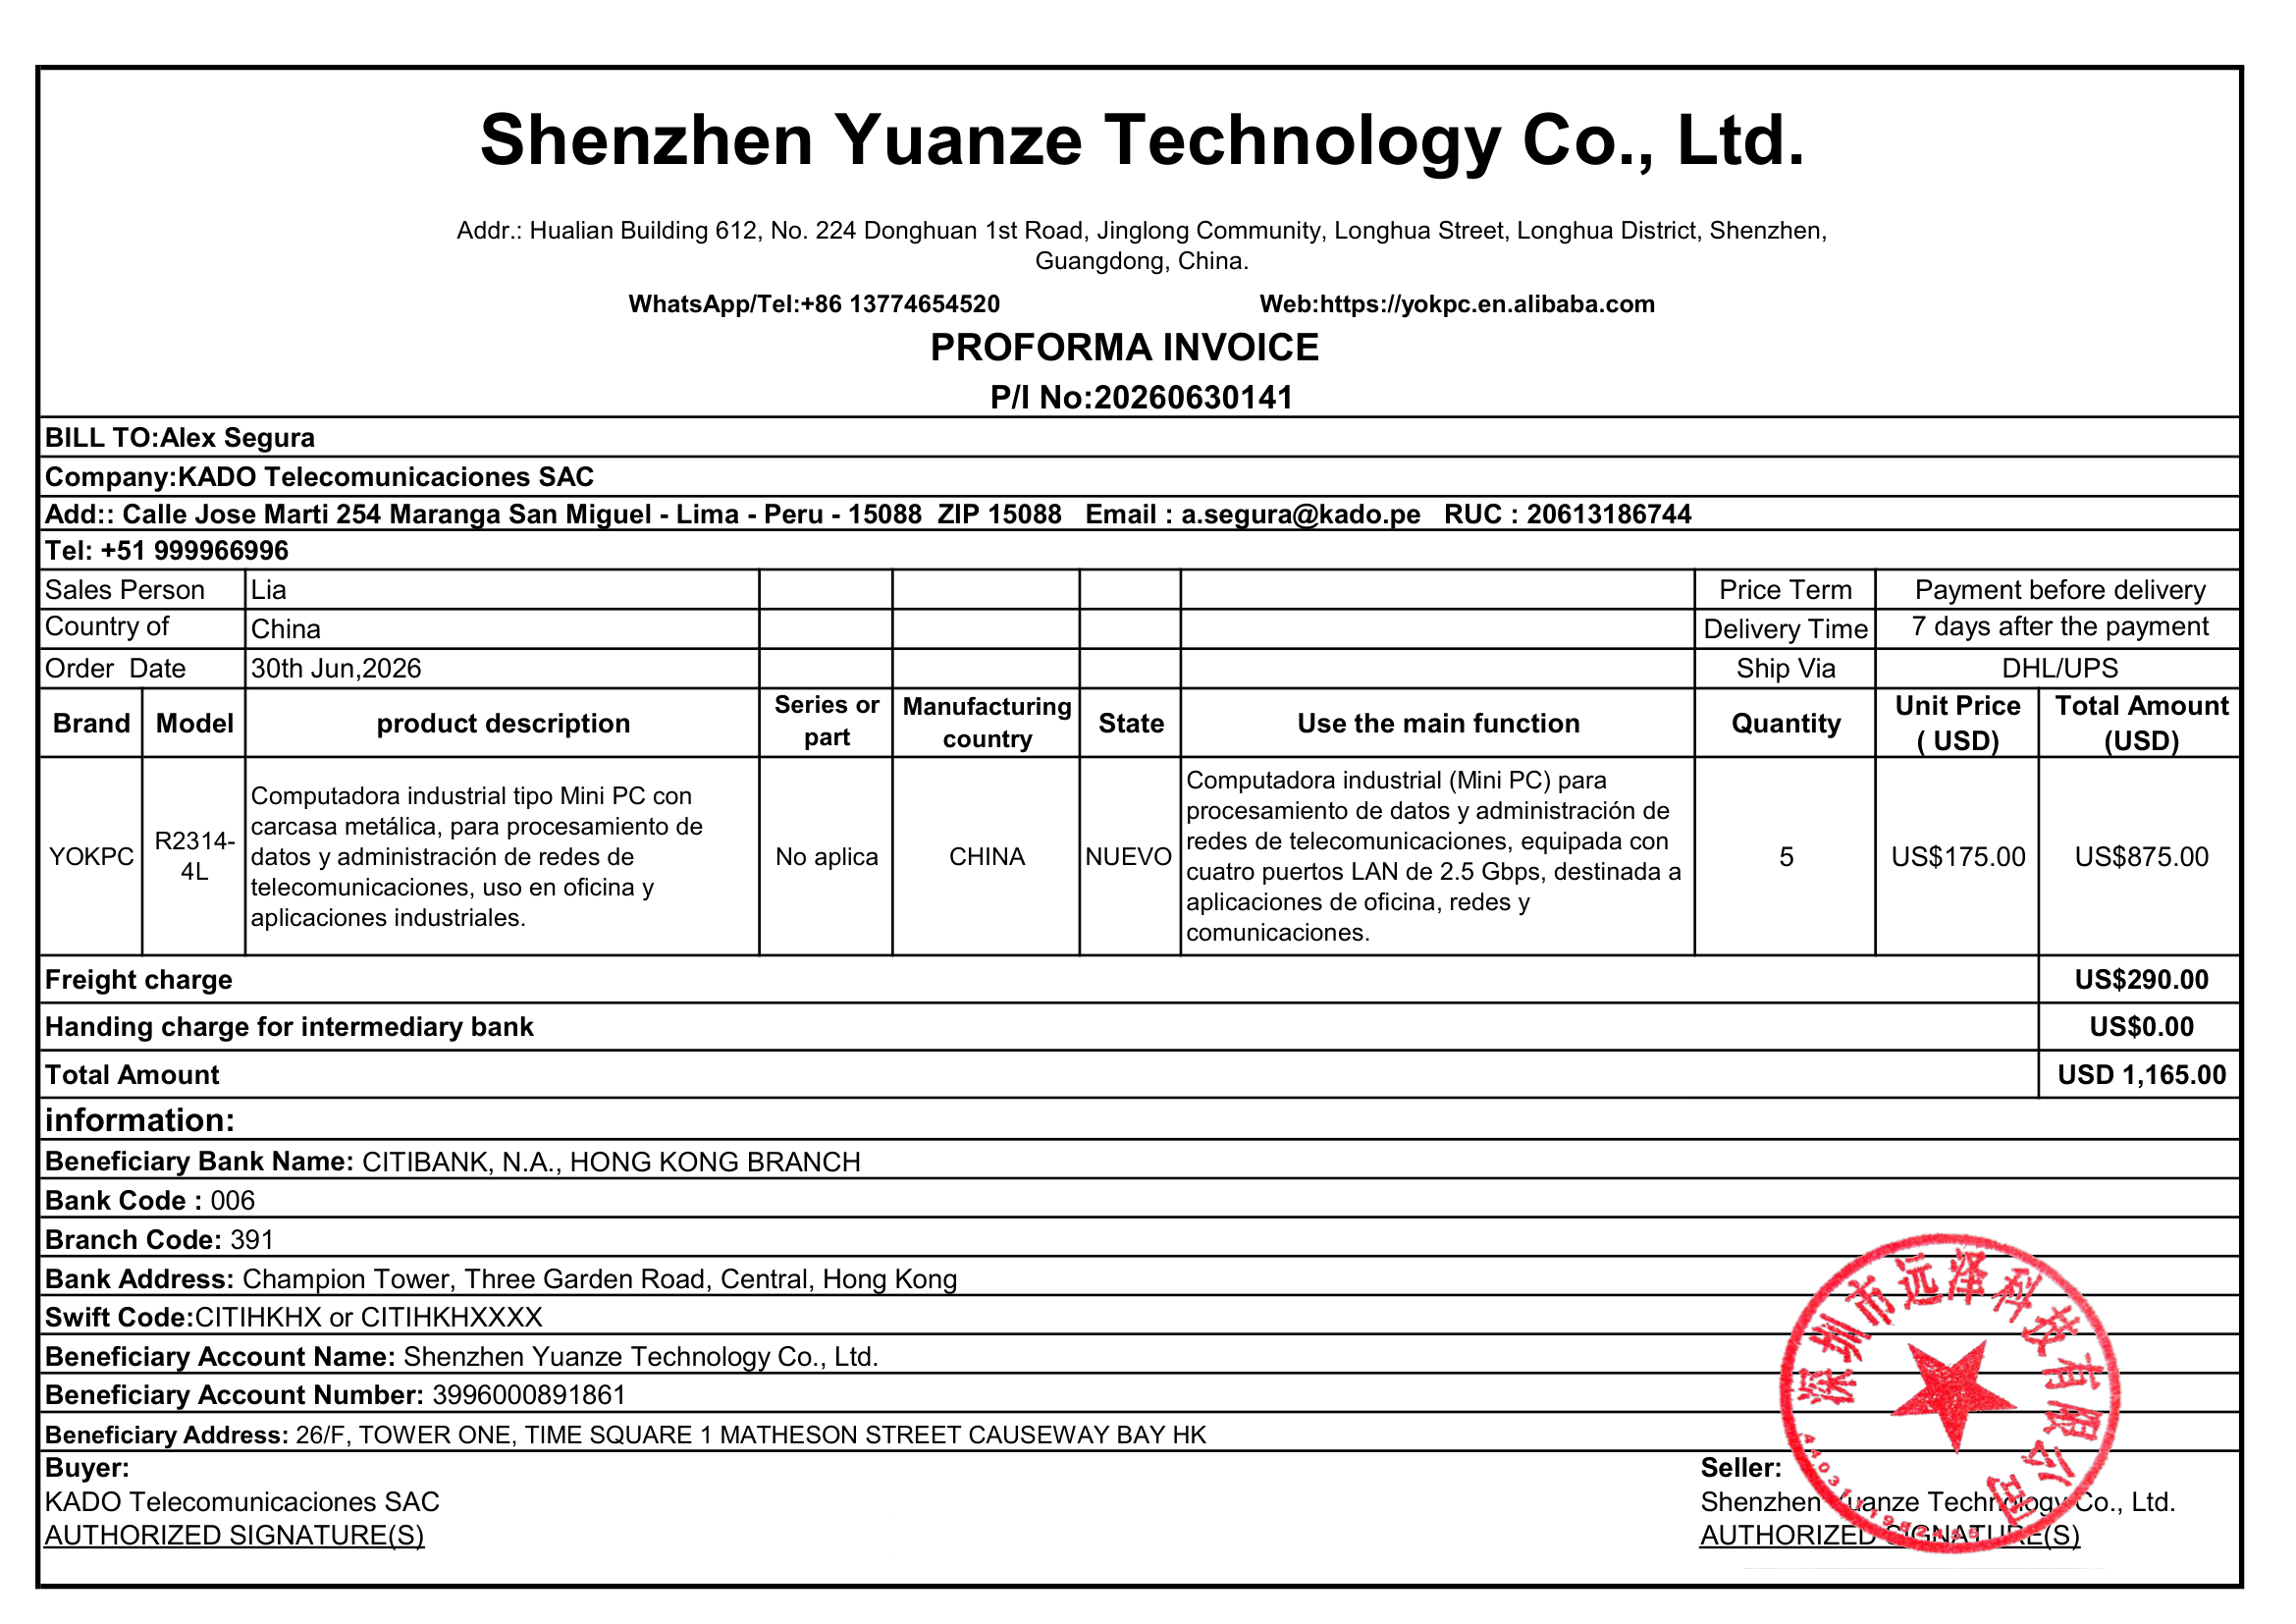

In [5]:
import fitz  # PyMuPDF

def pdf_a_imagenes(pdf_path: Path, dpi: int = 200) -> list[Path]:
    """Renderiza cada página del PDF a un PNG y devuelve las rutas generadas."""
    rutas = []
    doc = fitz.open(pdf_path)
    zoom = dpi / 72
    matriz = fitz.Matrix(zoom, zoom)
    for i, page in enumerate(doc):
        pix = page.get_pixmap(matrix=matriz)
        out = IMG_DIR / f"{pdf_path.stem}_p{i+1}.png"
        pix.save(out)
        rutas.append(out)
    doc.close()
    return rutas

IMG_PATHS = pdf_a_imagenes(PDF_PATH)
IMG_PATH = IMG_PATHS[0]  # el documento de demo tiene una sola página
print("Imagen(es) generada(s):", [str(p) for p in IMG_PATHS])

# Vista previa
from IPython.display import Image, display
display(Image(filename=str(IMG_PATH), width=520))

## 4. Reglas Python (normalización + extractor regex de respaldo)

Utilidades compartidas por ambas rutas:
- **Normalización** de montos (quita `US$`, comas, etc.) y de texto (espacios/mayúsculas) para comparar de forma justa.
- **Extractor por regex** que sirve como *fallback* de la Ruta 1 cuando OpenAI no está disponible, y como red de seguridad para validar los montos.

In [4]:
import re

CAMPOS_NUMERICOS = {
    "total_amount_usd",
    "freight_charge",
    "handling_charge_intermediary_bank",
    "total_amount",
}

def normaliza_monto(valor):
    """Convierte 'US$1,165.00' / '1165' / 1165.0 -> 1165.0 (float) o None."""
    if valor is None:
        return None
    if isinstance(valor, (int, float)):
        return float(valor)
    s = str(valor)
    s = re.sub(r"[^0-9.,]", "", s)          # deja dígitos, coma y punto
    s = s.replace(",", "")                    # comas = separador de miles
    if s in ("", "."):
        return None
    try:
        return float(s)
    except ValueError:
        return None

def normaliza_texto(valor):
    """Colapsa espacios y normaliza para comparación textual."""
    if valor is None:
        return ""
    return re.sub(r"\s+", " ", str(valor)).strip()

def normaliza_registro(d: dict) -> dict:
    """Aplica la normalización correspondiente a cada campo."""
    out = {}
    for c in CAMPOS:
        v = d.get(c)
        out[c] = normaliza_monto(v) if c in CAMPOS_NUMERICOS else normaliza_texto(v)
    return out


def extraer_por_reglas(texto: str) -> dict:
    """Extractor de respaldo basado en regex sobre el texto OCR/plano."""
    t = re.sub(r"\s+", " ", texto)
    res = {c: None for c in CAMPOS}

    m = re.search(r"BILL\s*TO\s*:?\s*([A-Za-zÀ-ÿ.\- ]+?)\s*(?:Company|Add|Tel|$)", t, re.I)
    if m:
        res["bill_to"] = m.group(1).strip()

    m = re.search(r"Company\s*:?\s*(.+?)\s*(?:Add|Tel|Sales|$)", t, re.I)
    if m:
        res["company"] = m.group(1).strip()

    m = re.search(r"Add\.?\s*:*\s*(.+?)\s*(?:Tel\s*:|Sales\s*Person)", t, re.I)
    if m:
        res["address"] = m.group(1).strip(" :")

    # Montos por etiqueta
    def monto(patron):
        mm = re.search(patron, t, re.I)
        return normaliza_monto(mm.group(1)) if mm else None

    res["freight_charge"] = monto(r"Freight\s*charge\s*US?\$?\s*([\d.,]+)")
    res["handling_charge_intermediary_bank"] = monto(
        r"Hand(?:l)?ing\s*charge\s*for\s*intermediary\s*bank\s*US?\$?\s*([\d.,]+)"
    )
    res["total_amount"] = monto(r"Total\s*Amount\s*USD\s*([\d.,]+)")

    # total_amount_usd = total de la línea de producto (último "US$xxx" antes de Freight)
    seg = t.split("Freight")[0]
    montos = re.findall(r"US?\$\s*([\d.,]+)", seg)
    if montos:
        res["total_amount_usd"] = normaliza_monto(montos[-1])

    return res

print("Utilidades de reglas Python listas.")

Utilidades de reglas Python listas.


## 5. Ruta 1 — PaddleOCR + OpenAI

### 5.1 OCR con PaddleOCR

Extraemos todo el texto de la imagen. La primera ejecución descarga los modelos de PaddleOCR (requiere internet).

In [6]:
import time
from paddleocr import PaddleOCR

# Inicialización (desactivamos módulos de orientación/desenrollado que no necesitamos aquí)
_t0 = time.time()
ocr_engine = PaddleOCR(
    lang="en",
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
)
print(f"PaddleOCR inicializado en {time.time()-_t0:.1f}s")

def ocr_texto(img_path: Path) -> tuple[str, list]:
    """Devuelve (texto_concatenado, lista_de_lineas) usando la API predict() de PaddleOCR 3.x."""
    resultado = ocr_engine.predict(str(img_path))
    lineas = []
    for res in resultado:
        # PaddleOCR 3.x expone los textos reconocidos en res['rec_texts']
        textos = res.get("rec_texts") if hasattr(res, "get") else None
        if textos is None and isinstance(res, dict):
            textos = res.get("rec_texts", [])
        lineas.extend(list(textos or []))
    return "\n".join(lineas), lineas

_t0 = time.time()
OCR_TEXTO, OCR_LINEAS = ocr_texto(IMG_PATH)
print(f"OCR completado en {time.time()-_t0:.1f}s | {len(OCR_LINEAS)} líneas\n")
print(OCR_TEXTO)

/Users/soporte/Downloads/project/dhl2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/soporte/Downloads/project/dhl2/.venv/lib/python3.13/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/soporte/Downloads/project/dhl2/.cache/paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please d

PaddleOCR inicializado en 2.0s
OCR completado en 38.2s | 79 líneas

Shenzhen Yuanze Technology Co., Ltd.
Addr.: Hualian Building 612, No. 224 Donghuan 1st Road, Jinglong Community, Longhua Street, Longhua District, Shenzhen,
Guangdong, China.
WhatsApp/Tel:+86 13774654520
Web:https://yokpc.en.alibaba.com
PROFORMA INVOICE
P/L No:20260630141
BILL TO:Alex Segura
Company:KADO Telecomunicaciones SAC
Add:: Calle Jose Marti 254 Maranga San Miguel - Lima - Peru - 15088 ZIP 15088 Email : a.segura@kado.pe RUC : 20613186744
Tel: +51 999966996
Sales Person
Lia
Price Term
Payment before delivery
Country of
China
Delivery Time
7 days after the payment
Order Date
30th Jun,2026
Ship Via
DHL/UPS
Series or
Manufacturing
Unit Price
Total Amount
Brand
Model
product description
State
Use the main function
Quantity
part
country
(USD)
(USD)
Computadora industrial (Mini PC) para
Computadora industrial tipo Mini PC con
procesamiento de datos y administración de
carcasa metálica, para procesamiento de
R2314-
red

### 5.2 Estructuración con LLM de OpenAI

El texto OCR se pasa a un LLM que devuelve un JSON con los campos objetivo. Si no hay `OPENAI_API_KEY` o falla la llamada, se cae automáticamente al **extractor por reglas Python**.

In [6]:
PROMPT_SISTEMA = (
    "Eres un asistente experto en extraer datos estructurados de facturas "
    "(Proforma Invoice). Devuelve SIEMPRE un JSON válido con exactamente estas "
    "claves: bill_to, company, address, total_amount_usd, freight_charge, "
    "handling_charge_intermediary_bank, total_amount. "
    "Los montos deben ser números (sin símbolos ni comas de miles). "
    "Si un campo no aparece, usa null."
)

def prompt_usuario(texto_ocr: str) -> str:
    return (
        "Extrae los campos objetivo del siguiente texto OCR de una Proforma Invoice.\n"
        "- total_amount_usd = 'Total Amount (USD)' de la línea del producto.\n"
        "- total_amount = 'Total Amount USD' final del documento.\n\n"
        f"TEXTO OCR:\n\"\"\"\n{texto_ocr}\n\"\"\""
    )

def extraer_openai(texto_ocr: str) -> dict:
    """Estructura el texto OCR con OpenAI. Lanza excepción si no es posible."""
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    resp = client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": PROMPT_SISTEMA},
            {"role": "user", "content": prompt_usuario(texto_ocr)},
        ],
        response_format={"type": "json_object"},
        temperature=0,
    )
    return json.loads(resp.choices[0].message.content)

# --- Ejecución de la Ruta 1 con fallback ---
ruta1_metodo = None
try:
    if not OPENAI_API_KEY:
        raise RuntimeError("OPENAI_API_KEY no configurada")
    _t0 = time.time()
    resultado_ruta1 = extraer_openai(OCR_TEXTO)
    ruta1_metodo = f"PaddleOCR + OpenAI ({OPENAI_MODEL})"
    print(f"Extracción OpenAI OK en {time.time()-_t0:.1f}s")
except Exception as e:
    print(f"[Fallback] OpenAI no disponible ({e}). Usando reglas Python sobre el texto OCR.")
    resultado_ruta1 = extraer_por_reglas(OCR_TEXTO)
    ruta1_metodo = "PaddleOCR + reglas Python (fallback)"

RESULTADO_RUTA1 = normaliza_registro(resultado_ruta1)
print("\nMétodo Ruta 1:", ruta1_metodo)
print(json.dumps(RESULTADO_RUTA1, indent=2, ensure_ascii=False))

Extracción OpenAI OK en 5.0s

Método Ruta 1: PaddleOCR + OpenAI (gpt-4o-mini)
{
  "bill_to": "Alex Segura",
  "company": "KADO Telecomunicaciones SAC",
  "address": "Calle Jose Marti 254 Maranga San Miguel - Lima - Peru - 15088 ZIP 15088",
  "total_amount_usd": 875.0,
  "freight_charge": 290.0,
  "handling_charge_intermediary_bank": 0.0,
  "total_amount": 1165.0
}


## 6. Ruta 2 — Qwen2.5-VL (local en `192.168.12.57`)

El modelo de visión-lenguaje recibe **la imagen directamente** (sin OCR previo) codificada en base64, y devuelve el mismo JSON de campos. Usamos el cliente OpenAI apuntando al endpoint local (formato OpenAI-compatible, típico en vLLM / Ollama / LM Studio).

Si el servidor no responde, la celda lo reporta y deja los campos en `null` para no interrumpir la comparación.

In [7]:
import base64

def imagen_a_data_url(img_path: Path) -> str:
    b64 = base64.b64encode(img_path.read_bytes()).decode()
    return f"data:image/png;base64,{b64}"

def extraer_qwen(img_path: Path) -> dict:
    """Extrae los campos con Qwen2.5-VL vía endpoint OpenAI-compatible local."""
    from openai import OpenAI
    client = OpenAI(base_url=QWEN_BASE_URL, api_key=QWEN_API_KEY, timeout=120)
    resp = client.chat.completions.create(
        model=QWEN_MODEL,
        messages=[
            {"role": "system", "content": PROMPT_SISTEMA},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt_usuario("(usa la imagen adjunta de la factura)")},
                    {"type": "image_url", "image_url": {"url": imagen_a_data_url(img_path)}},
                ],
            },
        ],
        temperature=0,
        max_tokens=1024,
    )
    contenido = resp.choices[0].message.content
    # Algunos servidores no respetan json_object: extraemos el primer bloque JSON.
    try:
        return json.loads(contenido)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", contenido, re.S)
        if not m:
            raise ValueError(f"Respuesta sin JSON: {contenido[:200]}")
        return json.loads(m.group(0))

# --- Ejecución de la Ruta 2 ---
qwen_disponible = True
try:
    _t0 = time.time()
    resultado_ruta2 = extraer_qwen(IMG_PATH)
    print(f"Extracción Qwen2.5-VL OK en {time.time()-_t0:.1f}s")
except Exception as e:
    qwen_disponible = False
    print(f"[Aviso] Qwen2.5-VL no disponible en {QWEN_BASE_URL} ({type(e).__name__}: {e}).")
    print("Se dejan los campos vacíos. Verifica el servidor y vuelve a ejecutar esta celda.")
    resultado_ruta2 = {c: None for c in CAMPOS}

RESULTADO_RUTA2 = normaliza_registro(resultado_ruta2)
print("\nMétodo Ruta 2: Qwen2.5-VL (" + QWEN_MODEL + ")")
print(json.dumps(RESULTADO_RUTA2, indent=2, ensure_ascii=False))

Extracción Qwen2.5-VL OK en 16.1s

Método Ruta 2: Qwen2.5-VL (Qwen/Qwen2.5-VL-32B-Instruct-AWQ)
{
  "bill_to": "Alex Segura",
  "company": "KADO Telecomunicaciones SAC",
  "address": "Calle Jose Marti 254 Maranga San Miguel-Lima-Peru-15088 ZIP 15088",
  "total_amount_usd": 875.0,
  "freight_charge": 290.0,
  "handling_charge_intermediary_bank": 0.0,
  "total_amount": 1165.0
}


## 7. Comparación y precisión

Comparamos cada ruta contra el *ground truth*, campo por campo:
- **Campos numéricos:** aciertan si el valor coincide exactamente (tras normalizar).
- **Campos de texto:** se calcula una **similitud** (0–1) con `difflib`; se consideran acierto si la similitud ≥ 0.90.

La **precisión global** de cada ruta = (campos acertados) / (total de campos).

In [8]:
import pandas as pd
from difflib import SequenceMatcher

UMBRAL_TEXTO = 0.90

def similitud(a, b, campo) -> float:
    """Devuelve una puntuación 0-1 comparando un valor con el ground truth."""
    if campo in CAMPOS_NUMERICOS:
        if a is None or b is None:
            return 0.0
        return 1.0 if abs(float(a) - float(b)) < 1e-6 else 0.0
    a_n = normaliza_texto(a).lower()
    b_n = normaliza_texto(b).lower()
    if not a_n and not b_n:
        return 1.0
    return SequenceMatcher(None, a_n, b_n).ratio()

def evaluar(resultado: dict) -> pd.DataFrame:
    filas = []
    for c in CAMPOS:
        gt = GROUND_TRUTH[c]
        pred = resultado.get(c)
        sim = similitud(pred, gt, c)
        acierto = sim >= (1.0 if c in CAMPOS_NUMERICOS else UMBRAL_TEXTO)
        filas.append({
            "campo": c,
            "ground_truth": gt,
            "extraido": pred,
            "similitud": round(sim, 3),
            "acierto": "OK" if acierto else "X",
        })
    return pd.DataFrame(filas)

gt_norm = normaliza_registro(GROUND_TRUTH)
eval_r1 = evaluar(RESULTADO_RUTA1)
eval_r2 = evaluar(RESULTADO_RUTA2)

print("=== RUTA 1:", ruta1_metodo, "===")
display(eval_r1)
print("=== RUTA 2: Qwen2.5-VL", "(disponible)" if qwen_disponible else "(NO disponible)", "===")
display(eval_r2)

=== RUTA 1: PaddleOCR + OpenAI (gpt-4o-mini) ===


,campo,ground_truth,extraido,similitud,acierto
0,bill_to,Alex Segura,Alex Segura,1.0,OK
1,company,KADO Telecomunicaciones SAC,KADO Telecomunicaciones SAC,1.0,OK
2,address,Calle Jose Marti 254 Maranga San Miguel - Lima...,Calle Jose Marti 254 Maranga San Miguel - Lima...,1.0,OK
3,total_amount_usd,875.0,875.0,1.0,OK
4,freight_charge,290.0,290.0,1.0,OK
5,handling_charge_intermediary_bank,0.0,0.0,1.0,OK
6,total_amount,1165.0,1165.0,1.0,OK


=== RUTA 2: Qwen2.5-VL (disponible) ===


,campo,ground_truth,extraido,similitud,acierto
0,bill_to,Alex Segura,Alex Segura,1.000,OK
1,company,KADO Telecomunicaciones SAC,KADO Telecomunicaciones SAC,1.000,OK
2,address,Calle Jose Marti 254 Maranga San Miguel - Lima...,Calle Jose Marti 254 Maranga San Miguel-Lima-P...,0.956,OK
3,total_amount_usd,875.0,875.0,1.000,OK
4,freight_charge,290.0,290.0,1.000,OK
5,handling_charge_intermediary_bank,0.0,0.0,1.000,OK
6,total_amount,1165.0,1165.0,1.000,OK


In [9]:
# --- Tabla comparativa lado a lado ---
comparativa = pd.DataFrame({
    "campo": CAMPOS,
    "ground_truth": [GROUND_TRUTH[c] for c in CAMPOS],
    "ruta1_extraido": [RESULTADO_RUTA1.get(c) for c in CAMPOS],
    "ruta1_sim": eval_r1["similitud"].values,
    "ruta1_ok": eval_r1["acierto"].values,
    "ruta2_extraido": [RESULTADO_RUTA2.get(c) for c in CAMPOS],
    "ruta2_sim": eval_r2["similitud"].values,
    "ruta2_ok": eval_r2["acierto"].values,
})
display(comparativa)

# --- Precisión global ---
def precision(df):
    return (df["acierto"] == "OK").mean()

prec_r1 = precision(eval_r1)
prec_r2 = precision(eval_r2)
simmed_r1 = eval_r1["similitud"].mean()
simmed_r2 = eval_r2["similitud"].mean()

resumen = pd.DataFrame({
    "Ruta": [ruta1_metodo, f"Qwen2.5-VL ({QWEN_MODEL})"],
    "Campos correctos": [f"{int((eval_r1['acierto']=='OK').sum())}/{len(CAMPOS)}",
                          f"{int((eval_r2['acierto']=='OK').sum())}/{len(CAMPOS)}"],
    "Precisión global": [f"{prec_r1:.1%}", f"{prec_r2:.1%}"],
    "Similitud media": [f"{simmed_r1:.3f}", f"{simmed_r2:.3f}"],
})
print("\n===================  RESUMEN DE PRECISIÓN  ===================")
display(resumen)

,campo,ground_truth,ruta1_extraido,ruta1_sim,ruta1_ok,ruta2_extraido,ruta2_sim,ruta2_ok
0,bill_to,Alex Segura,Alex Segura,1.0,OK,Alex Segura,1.000,OK
1,company,KADO Telecomunicaciones SAC,KADO Telecomunicaciones SAC,1.0,OK,KADO Telecomunicaciones SAC,1.000,OK
2,address,Calle Jose Marti 254 Maranga San Miguel - Lima...,Calle Jose Marti 254 Maranga San Miguel - Lima...,1.0,OK,Calle Jose Marti 254 Maranga San Miguel-Lima-P...,0.956,OK
3,total_amount_usd,875.0,875.0,1.0,OK,875.0,1.000,OK
4,freight_charge,290.0,290.0,1.0,OK,290.0,1.000,OK
5,handling_charge_intermediary_bank,0.0,0.0,1.0,OK,0.0,1.000,OK
6,total_amount,1165.0,1165.0,1.0,OK,1165.0,1.000,OK



===================  RESUMEN DE PRECISIÓN  ===================


,Ruta,Campos correctos,Precisión global,Similitud media
0,PaddleOCR + OpenAI (gpt-4o-mini),7/7,100.0%,1.000
1,Qwen2.5-VL (Qwen/Qwen2.5-VL-32B-Instruct-AWQ),7/7,100.0%,0.994


In [10]:
# --- Conclusión automática ---
def veredicto(p1, p2):
    if abs(p1 - p2) < 1e-9:
        return "Ambas rutas obtuvieron la misma precisión global."
    ganadora = "Ruta 1 (PaddleOCR + OpenAI)" if p1 > p2 else "Ruta 2 (Qwen2.5-VL)"
    return f"Mejor precisión: {ganadora} ({max(p1, p2):.1%} vs {min(p1, p2):.1%})."

print("Ruta 1 -> precisión {:.1%} | similitud media {:.3f}".format(prec_r1, simmed_r1))
print("Ruta 2 -> precisión {:.1%} | similitud media {:.3f}".format(prec_r2, simmed_r2))
print()
if not qwen_disponible:
    print("Nota: Qwen2.5-VL no estaba disponible; su precisión no es representativa.")
    print("Levanta el servidor en 192.168.12.57 y re-ejecuta la sección 6 para una comparación real.")
else:
    print(veredicto(prec_r1, prec_r2))

# Diferencias por campo entre ambas rutas
difs = comparativa[comparativa["ruta1_extraido"].astype(str) != comparativa["ruta2_extraido"].astype(str)]
if len(difs):
    print("\nCampos donde las rutas difieren:")
    display(difs[["campo", "ruta1_extraido", "ruta2_extraido", "ground_truth"]])
else:
    print("\nAmbas rutas coincidieron en todos los campos.")

Ruta 1 -> precisión 100.0% | similitud media 1.000
Ruta 2 -> precisión 100.0% | similitud media 0.994

Ambas rutas obtuvieron la misma precisión global.

Campos donde las rutas difieren:


,campo,ruta1_extraido,ruta2_extraido,ground_truth
2,address,Calle Jose Marti 254 Maranga San Miguel - Lima...,Calle Jose Marti 254 Maranga San Miguel-Lima-P...,Calle Jose Marti 254 Maranga San Miguel - Lima...
